In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Update projections onto decoder axes

Results of `scripts/pseudo_decoding/belief_partitions/decoder_update_projections.py`.

- For each (session, feature X) there are 8 pair splits. In each split, half of each chose-X cell (outcome x partition on trial k) are test trials k; k and k+1 are reserved; the remaining trials are axis trials.
- Split i's pref (High X vs. High Not X) and conf (High vs. Low) decoders are trained on split i's axis trials only, using the `*_99th_no_cond_window_filter_drift` units.
- Each test trial's change in pre-stimulus activity, x[k+1] - x[k], is projected per bin onto split i's axis and averaged over bins.

Each value is the mean, across (session, feature, split) units, of a cell's mean projection, with each (feature, split) axis scaled to unit length. Error bars are SE across units.

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/data/patrick_res/decoder_update_projections/both_StimOnset"

def read(name):
    # return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_{name}.pickle"))
    # return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_axis_norm_{name}.pickle"))
    # return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_old_axes_{name}.pickle"))
    return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_chunk_20_train_frac_0.3_{name}.pickle"))
    # return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_chunk_20_train_frac_0.3_min_std_0_{name}.pickle"))

stats = read("stats")
cells = read("cells")
events = read("events")

## Tests

One-sided sign-flip tests, flips per (session, feature, split). Each contrast is signed so the hypothesis predicts a positive value.

In [10]:
stats[["contrast", "axis", "plus", "minus", "mean_d", "n_units", "p"]].round(4)

,contrast,axis,plus,minus,mean_d,n_units,p
0,conf_cor,conf,cor/Low,cor/High,0.1725,2400,0.0001
1,conf_inc,conf,inc/Low,inc/High,0.2052,2400,0.0001
2,pref_cor,pref,cor/Low,cor/High X,0.0085,2248,0.0016
3,pref_inc,pref,inc/High Not X,inc/High X,0.0346,2091,0.0001


## Decoder test accuracy

Pre-stimulus test accuracy of the decoders the projections above used, averaged over the 10 pre-stimulus bins and the 8 splits. For the new decoders, each split's accuracy is on that split's test trials k (their activity on trial k). The old no-cond decoders' accuracy is on their own random 20% held-out trials, so the two aren't directly comparable.

`TEST_FRAC` and `OLD_AXES` must match the run `read()` loads.

In [11]:
from constants.behavioral_constants import FEATURES
from scripts.pseudo_decoding.belief_partitions.decode_update_axes import decoder_base_path
from scripts.pseudo_decoding.belief_partitions.decoder_update_projections import OLD_DECODER_PATH, SIG_UNIT_LEVEL

TEST_FRAC = 0.7
OLD_AXES = False
N_PRE_STIM_BINS = 10

def decoder_accs(mode):
    base = OLD_DECODER_PATH if OLD_AXES else decoder_base_path(TEST_FRAC)
    dir_name = os.path.join(base, f"both_StimOnset_{SIG_UNIT_LEVEL.format(mode=mode)}_units")
    # bins x splits; the old decoders cover the whole StimOnset interval, whose first 10 bins are pre-stim
    return pd.Series({
        feat: np.load(os.path.join(dir_name, f"{feat}_{mode}_test_accs.npy"))[:N_PRE_STIM_BINS].mean()
        for feat in FEATURES
    })

accs = pd.DataFrame({mode: decoder_accs(mode) for mode in ["pref", "conf"]})
accs.loc["mean"] = accs.mean()
accs.round(3)

,pref,conf
CIRCLE,0.537,0.906
SQUARE,0.579,0.899
STAR,0.582,0.870
TRIANGLE,0.563,0.844
CYAN,0.563,0.899
GREEN,0.592,0.898
MAGENTA,0.522,0.910
YELLOW,0.590,0.913
ESCHER,0.552,0.891
POLKADOT,0.587,0.897


## Cell means

Chose-X test trials, by outcome and belief partition on trial k. For conf, High pools High X and High Not X.

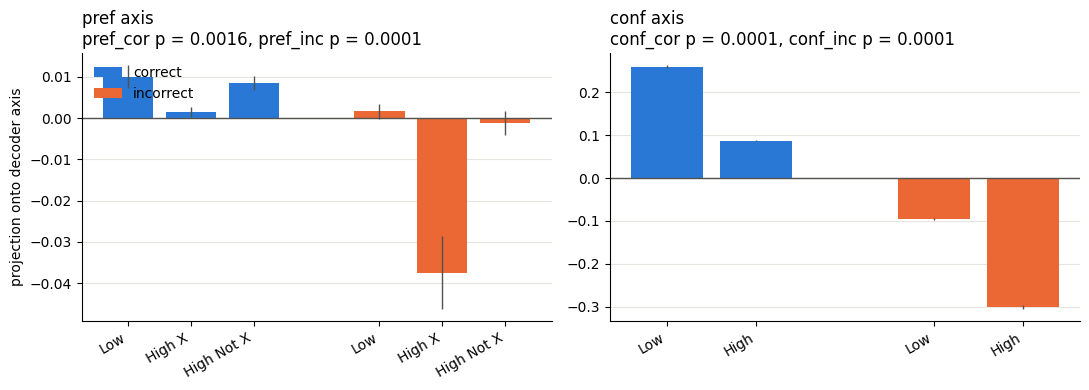

In [12]:
AXIS_PARTITIONS = {"pref": ["Low", "High X", "High Not X"], "conf": ["Low", "High"]}
# blue / orange rather than green / red: green / red fails the colorblind (deutan) separation check
OUTCOME_COLORS = {"cor": "#2a78d6", "inc": "#eb6834"}
OUTCOME_LABELS = {"cor": "correct", "inc": "incorrect"}

def plot_cells(ax, cells_df, axis_name, title):
    partitions = AXIS_PARTITIONS[axis_name]
    df = cells_df[cells_df.axis == axis_name].set_index("cell")
    for i, outcome in enumerate(["cor", "inc"]):
        x = np.arange(len(partitions)) + i * (len(partitions) + 1)
        rows = df.loc[[f"{outcome}/{p}" for p in partitions]]
        ax.bar(x, rows["mean"], yerr=rows["se"], width=0.8, color=OUTCOME_COLORS[outcome],
               linewidth=0, error_kw={"elinewidth": 1, "ecolor": "#52514e"},
               label=OUTCOME_LABELS[outcome])
    ticks = np.concatenate([np.arange(len(partitions)) + i * (len(partitions) + 1) for i in range(2)])
    ax.set_xticks(ticks)
    ax.set_xticklabels(partitions * 2, rotation=30, ha="right")
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.set_title(title, loc="left")

def p_str(axis_name):
    s = stats[stats.axis == axis_name].set_index("contrast")
    return ", ".join(f"{c} p = {s.loc[c, 'p']:.4f}" for c in s.index)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, axis_name in zip(axes, ["pref", "conf"]):
    plot_cells(ax, cells, axis_name, f"{axis_name} axis\n{p_str(axis_name)}")
axes[0].set_ylabel("projection onto decoder axis")
axes[0].legend(frameon=False, loc="upper left")
fig.tight_layout()

## Conditions

The conditions of `pref_conf_projection_updates.py`, laid out like its pre-stimulus bar plots in `20250625_visualize_update_projections.ipynb`. Chose X / correct and chose X / incorrect pool every chose-X test trial of that outcome over partitions. Correct and incorrect (lighter bars) also include the not-X trials of the chunk split's test blocks whose next trial is in the same block, so they only exist for chunk-split runs. There is no shuffle bar and there are no significance bars: these runs test by sign flips, and the conditions have no test yet.

,axis,condition,mean,se,n_units,n_events,p_vs_0
0,pref,chose X / cor,0.0069,0.0016,2248,257717,0.0001
1,pref,chose X / inc,-0.0007,0.0018,2248,168067,0.6897
2,pref,cor,0.0012,0.0012,2248,881231,0.2859
3,pref,inc,-0.0015,0.0016,2248,654092,0.3366
4,conf,chose X / cor,0.1385,0.0019,2400,272860,0.0001
5,conf,chose X / inc,-0.1864,0.0025,2400,178267,0.0001
6,conf,cor,0.1386,0.0018,2400,935299,0.0001
7,conf,inc,-0.1869,0.0024,2400,695628,0.0001


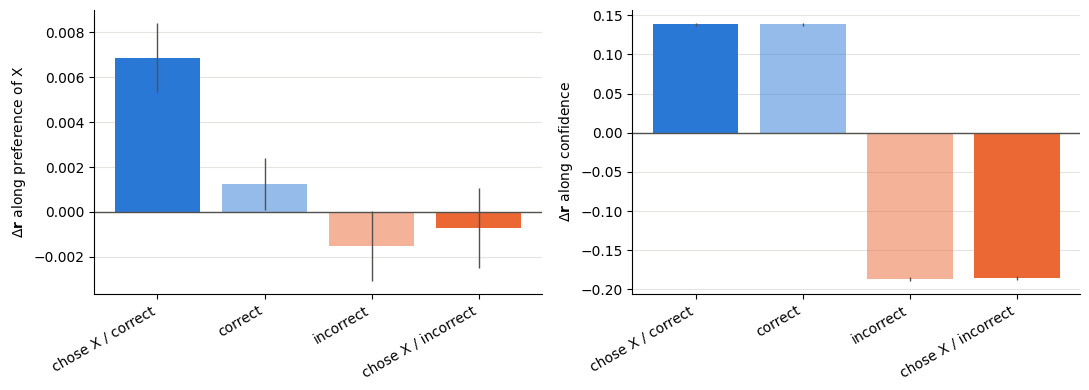

In [13]:
conditions = read("conditions")

CONDITION_ORDER = ["chose X / cor", "cor", "inc", "chose X / inc"]
CONDITION_LABELS = {"chose X / cor": "chose X / correct", "cor": "correct",
                    "inc": "incorrect", "chose X / inc": "chose X / incorrect"}
AXIS_YLABELS = {"pref": r"$\Delta \mathbf{r}$ along preference of X", "conf": r"$\Delta \mathbf{r}$ along confidence"}

def plot_conditions(ax, conditions_df, axis_name):
    df = conditions_df[conditions_df.axis == axis_name].set_index("condition")
    # the all-choice conditions are absent from pair-split runs
    order = [c for c in CONDITION_ORDER if c in df.index]
    for i, cond in enumerate(order):
        ax.bar(i, df.loc[cond, "mean"], yerr=df.loc[cond, "se"], width=0.8,
               color=OUTCOME_COLORS[cond.split(" / ")[-1]], alpha=1.0 if "chose X" in cond else 0.5,
               linewidth=0, error_kw={"elinewidth": 1, "ecolor": "#52514e"})
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels([CONDITION_LABELS[c] for c in order], rotation=30, ha="right")
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.set_ylabel(AXIS_YLABELS[axis_name])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, axis_name in zip(axes, ["pref", "conf"]):
    plot_conditions(ax, conditions, axis_name)
fig.tight_layout()

conditions.round(4)

## Counts

Test events per session, pooled over features, averaged over the 8 splits.

In [6]:
per_session = (events.groupby(["session", "split", "pref_cell"]).size()
               .unstack("pref_cell").fillna(0).groupby("session").mean())
order = [f"{o}/{p}" for o in ["cor", "inc"] for p in AXIS_PARTITIONS["pref"]]
pd.DataFrame({"median": per_session.median(), "min": per_session.min(),
              "sessions with 0": (per_session == 0).sum()}).loc[order]

,median,min,sessions with 0
pref_cell,,,
cor/Low,145.6250,19.625,0
cor/High X,141.3125,19.250,0
cor/High Not X,149.2500,13.250,0
inc/Low,152.4375,18.625,0
inc/High X,8.5625,0.625,0
inc/High Not X,115.2500,18.500,0
